In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from warnings import filterwarnings
filterwarnings('ignore')
%pip install yaml
import yaml, os
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement yaml (from versions: none)
ERROR: No matching distribution found for yaml


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import re
from sklearn.preprocessing import LabelEncoder

csv_path = r"C:\Users\Lenovo\OneDrive - Hanoi University of Science and Technology\Desktop\HUST\classes.csv"
train_img_dir = r"C:\Users\Lenovo\OneDrive - Hanoi University of Science and Technology\Desktop\HUST\Train-test"
val_img_dir = r"C:\Users\Lenovo\OneDrive - Hanoi University of Science and Technology\Desktop\HUST\valida"

df = pd.read_csv(csv_path, sep=';')
df = df.loc[:, ~df.columns.str.contains("Unnamed")]

train_names = pd.concat([df["Train–test"], df["Train–test.1"]]).dropna().tolist()
val_names = df["Validation"].dropna().tolist()

pattern = re.compile(r"(.+)-(\d+)-Ag-(\d+)_([A-D])")

def parse_csv_name(name):
    m = pattern.match(name)
    if not m:
        return None
    brand, num, idx, label = m.groups()
    key = f"{brand}-{int(num)}-Ag-{int(idx)}"
    return key, label

def parse_img_name(name):
    name = os.path.splitext(name)[0]
    name = name.replace("-Ori", "")
    parts = name.split("-")
    key = f"{parts[0]}-{int(parts[1])}-Ag-{int(parts[-1])}"
    return key

# index images
train_img_map = {}
for f in os.listdir(train_img_dir):
    if f.endswith(".tif"):
        train_img_map[parse_img_name(f)] = os.path.join(train_img_dir, f)

val_img_map = {}
for f in os.listdir(val_img_dir):
    if f.endswith(".tif"):
        val_img_map[parse_img_name(f)] = os.path.join(val_img_dir, f)

# match train
train_rows = []
train_labels = []

for name in train_names:
    parsed = parse_csv_name(name)
    if not parsed:
        continue
    key, label = parsed
    if key in train_img_map:
        train_rows.append(train_img_map[key])
        train_labels.append(label)

# match validation
val_rows = []
val_labels = []

for name in val_names:
    parsed = parse_csv_name(name)
    if not parsed:
        continue
    key, label = parsed
    if key in val_img_map:
        val_rows.append(val_img_map[key])
        val_labels.append(label)

# encode labels
le = LabelEncoder()
le.fit(train_labels + val_labels)

train_labels_enc = le.transform(train_labels)
val_labels_enc = le.transform(val_labels)

# create dataframes
train_df = pd.DataFrame({
    "file_path": train_rows,
    "label": train_labels_enc
})

val_df = pd.DataFrame({
    "file_path": val_rows,
    "label": val_labels_enc
})

# save
train_df.to_csv("train_data.csv", index=False)
val_df.to_csv("val_data.csv", index=False)

# report
print("Classes")
for i, c in enumerate(le.classes_):
    print(i, c)


Classes
0 A
1 B
2 C
3 D


In [4]:
print("Train rows: ", len(train_df))
print("Val rows: ", len(val_df))

Train rows:  5713
Val rows:  2001


In [5]:
df.describe()
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3117 entries, 0 to 3116
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Train–test    3117 non-null   object
 1   Train–test.1  2596 non-null   object
 2   Validation    2001 non-null   object
dtypes: object(3)
memory usage: 73.2+ KB


In [6]:
print(df.head(10))

           Train–test       Train–test.1       Validation
0  Pryntex-01-Ag-01_B  Botlek-01-Ag-10_B   762-27-Ag-10_B
1  Pryntex-01-Ag-02_D  Botlek-01-Ag-11_B  762-27-Ag-100_B
2  Pryntex-01-Ag-03_B  Botlek-01-Ag-12_D  762-27-Ag-101_B
3  Pryntex-01-Ag-04_B  Botlek-01-Ag-14_C  762-27-Ag-102_B
4  Pryntex-01-Ag-05_B  Botlek-01-Ag-15_B  762-27-Ag-103_B
5  Pryntex-01-Ag-06_B  Botlek-01-Ag-16_B  762-27-Ag-104_A
6  Pryntex-01-Ag-07_B  Botlek-01-Ag-17_B  762-27-Ag-105_A
7  Pryntex-01-Ag-08_B  Botlek-01-Ag-18_D  762-27-Ag-106_B
8  Pryntex-01-Ag-09_B  Botlek-01-Ag-19_D  762-27-Ag-107_D
9  Pryntex-01-Ag-10_B  Botlek-01-Ag-20_B  762-27-Ag-108_B


Train-test split 

In [7]:
from sklearn.model_selection import train_test_split
train_df_split, test_df_split = train_test_split(
    train_df,
    test_size=0.3,
    random_state=42,
    shuffle=True,
    stratify=train_df["label"], 
)

In [8]:
print(train_df_split.head())
print(test_df_split.head())

                                              file_path  label
1407  C:\Users\Lenovo\OneDrive - Hanoi University of...      2
4401  C:\Users\Lenovo\OneDrive - Hanoi University of...      2
4889  C:\Users\Lenovo\OneDrive - Hanoi University of...      1
5394  C:\Users\Lenovo\OneDrive - Hanoi University of...      3
3864  C:\Users\Lenovo\OneDrive - Hanoi University of...      3
                                              file_path  label
594   C:\Users\Lenovo\OneDrive - Hanoi University of...      1
4217  C:\Users\Lenovo\OneDrive - Hanoi University of...      2
5673  C:\Users\Lenovo\OneDrive - Hanoi University of...      1
545   C:\Users\Lenovo\OneDrive - Hanoi University of...      1
2066  C:\Users\Lenovo\OneDrive - Hanoi University of...      1


In [9]:
train_paths = train_df_split["file_path"].to_numpy()
train_labels = train_df_split["label"].to_numpy()

test_paths = test_df_split["file_path"].to_numpy()
test_labels = test_df_split["label"].to_numpy()

print(len(train_paths), len(train_labels)) #These numbers must be equal to each other in order to train
print(len(test_paths), len(test_labels))

3999 3999
1714 1714


In [10]:
val_paths = val_df["file_path"].to_numpy()
val_labels = val_df["label"].to_numpy()

print(len(val_paths), len(val_labels))

2001 2001


Define dataset class

In [11]:
%pip install torch

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [12]:
from torch.utils.data import Dataset
from PIL import Image
import torch
class CacbonDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = list(image_paths)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

As long as our train data is strongly overweighted (6%, **57%**, 14%, **22%** for class A B C D, respectively), so data augmentation is an unseparatable part

In [13]:
from torchvision import transforms

EFFICIENTNET_MEAN = [0.485, 0.456, 0.406]
EFFICIENTNET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(320),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(300),
    transforms.ColorJitter(
        brightness=0.2, 
        contrast=0.2,
        saturation=0.2,
        hue=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=EFFICIENTNET_MEAN, std=EFFICIENTNET_STD)
])

test_transform = transforms.Compose([
    transforms.Resize(320),
    transforms.CenterCrop(300),
    transforms.ToTensor(),
    transforms.Normalize(mean = EFFICIENTNET_MEAN, std = EFFICIENTNET_STD)
])

val_transform = test_transform

**DataLoader**

In [14]:
from torch.utils.data import DataLoader

train_dataset = CacbonDataset(
    image_paths=train_paths,
    labels=train_labels,
    transform=train_transform
)

test_dataset = CacbonDataset(
    image_paths=test_paths,
    labels=test_labels,
    transform=test_transform
)

val_dataset = CacbonDataset(
    image_paths=val_paths,
    labels=val_labels,
    transform=val_transform
)

In [15]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [17]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights

weights = EfficientNet_B3_Weights.IMAGENET1K_V1
model = efficientnet_b3(weights=weights)

num_classes = 4

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)

In [18]:
model = model.to(device)

Early stopping

In [19]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            return False

        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            return False
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
                return True
            return False

FocalLoss and Optimizer

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(
            logits,
            targets,
            weight=self.alpha,
            reduction='none'
        )

        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()


In [21]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)


In [22]:
class EarlyStopping:
    def __init__(self, patience=6, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            return False

        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            return False
        else:
            self.counter += 1
            return self.counter >= self.patience


In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np

num_epochs = 10
best_val_acc = 0.0

criterion = FocalLoss(gamma=2.5, alpha=[0.5544832379, 0.06033680116, 0.2308167252, 0.1543632358])
early_stopper = EarlyStopping(patience=6, min_delta=1e-4)

for epoch in range(num_epochs):

    # ===== TRAIN =====
    model.train()
    train_losses = []
    train_preds = []
    train_targets = []

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        train_preds.extend(outputs.argmax(1).cpu().numpy())
        train_targets.extend(labels.cpu().numpy())

    train_acc = accuracy_score(train_targets, train_preds)

    # ===== VALIDATION =====
    model.eval()
    val_losses = []
    val_preds = []
    val_targets = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_losses.append(loss.item())
            val_preds.extend(outputs.argmax(1).cpu().numpy())
            val_targets.extend(labels.cpu().numpy())

    val_loss = np.mean(val_losses)
    val_acc = accuracy_score(val_targets, val_preds)

    scheduler.step(val_loss)

    print(
        f"Epoch [{epoch+1:02d}/{num_epochs}] | "
        f"Train Loss {np.mean(train_losses):.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.4f}"
    )

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_efficientnet_b3.pth")

    # Early stopping
    if early_stopper(val_loss):
        print("Early stopping triggered")
        break


AttributeError: 'list' object has no attribute 'ToTensor'

In [ ]:
model.load_state_dict(torch.load("best_efficientnet_b3.pth"))
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
            (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActiv

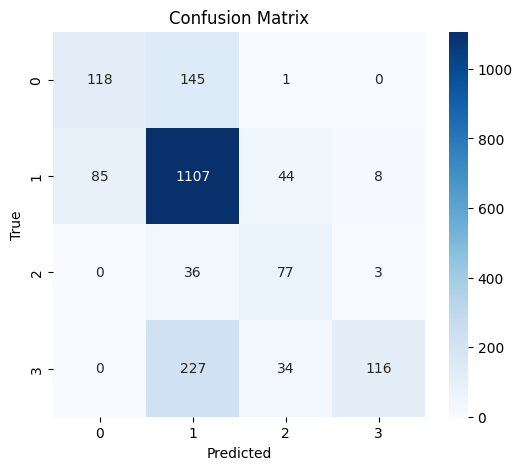

              precision    recall  f1-score   support

           0       0.58      0.45      0.51       264
           1       0.73      0.89      0.80      1244
           2       0.49      0.66      0.57       116
           3       0.91      0.31      0.46       377

    accuracy                           0.71      2001
   macro avg       0.68      0.58      0.58      2001
weighted avg       0.73      0.71      0.69      2001



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

model.load_state_dict(torch.load("best_efficientnet_b3.pth"))
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(all_targets, all_preds))


Ở đây, mô hình dự đoán class 1 khá là tốt. Thế nhưng! những class còn lại: 0,2 d